<a href="https://colab.research.google.com/github/ixau0-0/final-project/blob/main/03_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data=pd.read_csv('features_data.csv')
data

,age,sex,bmi,children,smoker,region,charges,bmi_per_age,smoker_numeric,charges_log,age_group_encoded
0,19,female,27.900,0,yes,southwest,16884.92400,1.468421,1,9.734236,1.0
1,18,male,33.770,1,no,southeast,1725.55230,1.876111,0,7.453882,0.0
2,28,male,33.000,3,no,southeast,4449.46200,1.178571,0,8.400763,1.0
3,33,male,22.705,0,no,northwest,21984.47061,0.688030,0,9.998137,1.0
4,32,male,28.880,0,no,northwest,3866.85520,0.902500,0,8.260455,1.0
...,...,...,...,...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830,0.619400,0,9.268755,2.0
1333,18,female,31.920,0,no,northeast,2205.98080,1.773333,0,7.699381,0.0
1334,18,female,36.850,0,no,southeast,1629.83350,2.047222,0,7.396847,0.0
1335,21,female,25.800,0,no,southwest,2007.94500,1.228571,0,7.605365,1.0


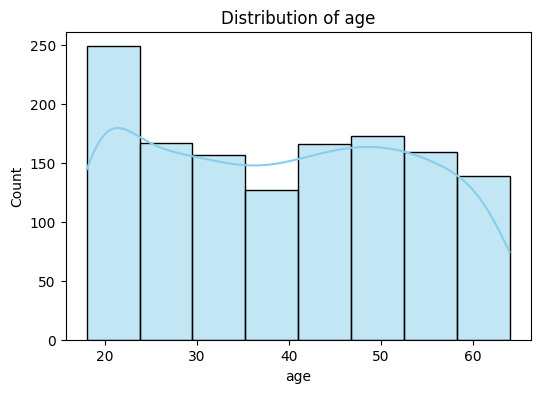

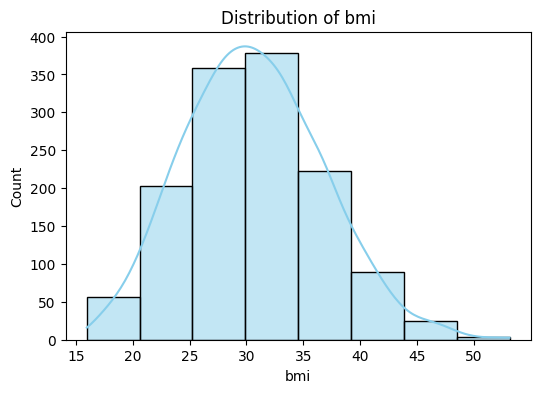

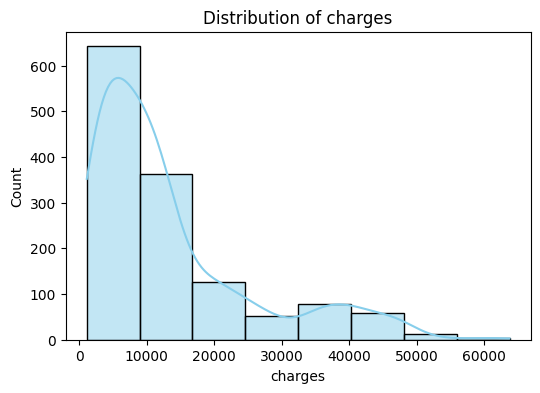

In [ ]:
num= ['age', 'bmi', 'charges']

for col in num:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True, bins=8, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

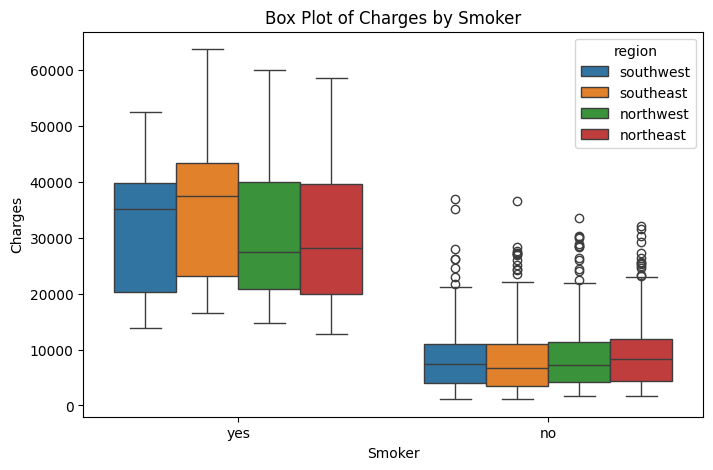

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges',hue="region", data=data)
plt.title('Box Plot of Charges by Smoker')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.savefig('chart_boxplot_smoker_region.png', dpi=300, bbox_inches='tight')
plt.show()

# يوضح اختلاف التكاليف لكل منطقة لكن يبقى التدخين العامل المؤثر على التكاليف

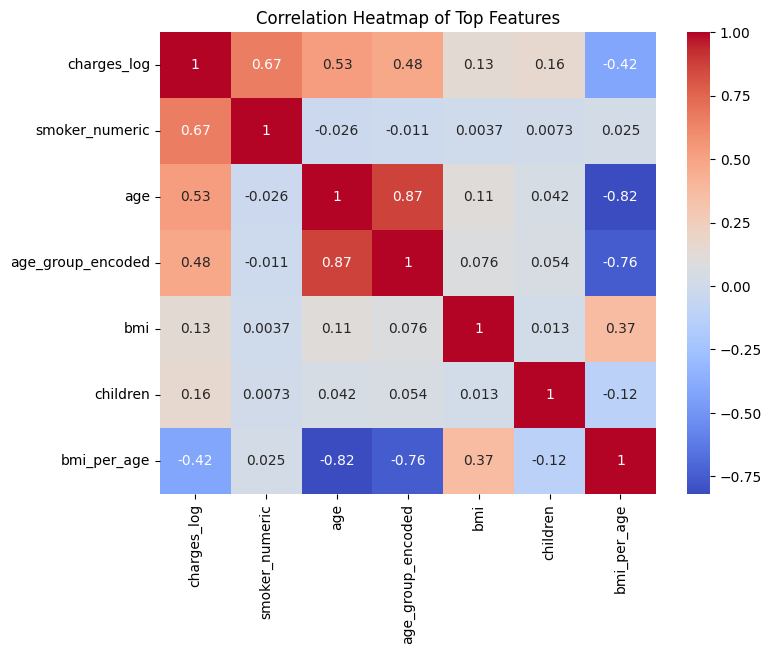

In [ ]:
num = data.select_dtypes(include=np.number)
corr_matrix = num.corr()
target_corr = corr_matrix['charges'].sort_values(ascending=False)

top_features = target_corr.index[1:11]

plt.figure(figsize=(8,6))
sns.heatmap(num[top_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Top Features')
plt.savefig('chart_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# بالتمثيل يوضح اقوى العلاقات واهم المتغيرات المرتبطة بالتكاليف

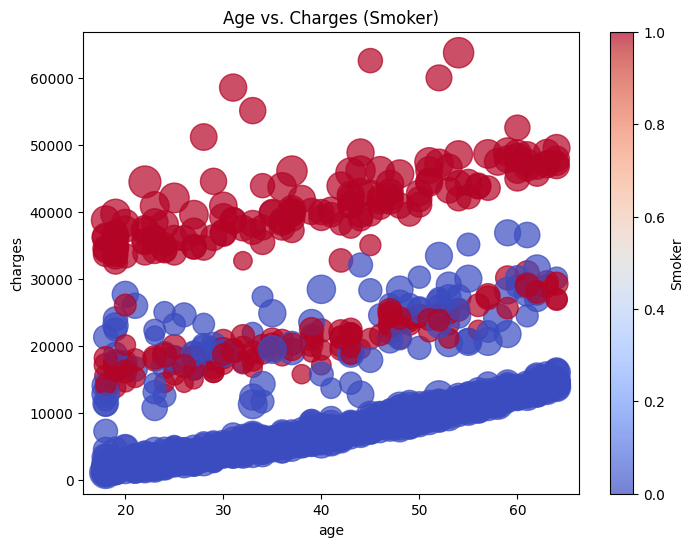

In [ ]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    x=data["age"],
    y=data["charges"],
    s=data["bmi"]*10,          # حجم النقاط يعتمد على BMI
    c=data["smoker_numeric"],     # لون النقاط يعتمد على smoker
    cmap="coolwarm",          # مجموعة ألوان
    alpha=0.7
)

plt.xlabel("age")
plt.ylabel("charges")
plt.colorbar(scatter, label="Smoker")
plt.title("Age vs. Charges (Smoker)")
plt.savefig('chart_age_charges_smoker.png', dpi=300, bbox_inches='tight')
plt.show()

#يوضح ان كلما زاد العمر زادت التكاليف وكلما زاد العمر زادت الكتلة ويوضح ايضا ان المدخنين هم اعلى الناس تكاليف

In [ ]:
cat = ["sex","smoker", "region"]
target_col = "charges"

for col in cat:
    grouped = data.groupby(col)[target_col].mean()
    print(f"\nمتوسط {target_col} حسب {col}:")
    print(grouped)

    highest_group = grouped.idxmax()
    highest_value = grouped.max()
    lowest_group = grouped.idxmin()
    lowest_value = grouped.min()

    print(f"أعلى مجموعة: {highest_group} → {highest_value}")
    print(f"أدنى مجموعة: {lowest_group} → {lowest_value}")
    #اكثر عامل مؤثر هو التدخين اكثر من الجنس و المنطقة


متوسط charges حسب sex:
sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64
أعلى مجموعة: male → 13974.998863762961
أدنى مجموعة: female → 12569.578843835347

متوسط charges حسب smoker:
smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64
أعلى مجموعة: yes → 32050.23183153285
أدنى مجموعة: no → 8440.660306508938

متوسط charges حسب region:
region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64
أعلى مجموعة: southeast → 14735.41143760989
أدنى مجموعة: southwest → 12346.937377292308


In [ ]:
from google.colab import files
files.download('chart_boxplot_smoker_region.png')
files.download('chart_age_charges_smoker.png')
files.download('chart_correlation_heatmap.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>